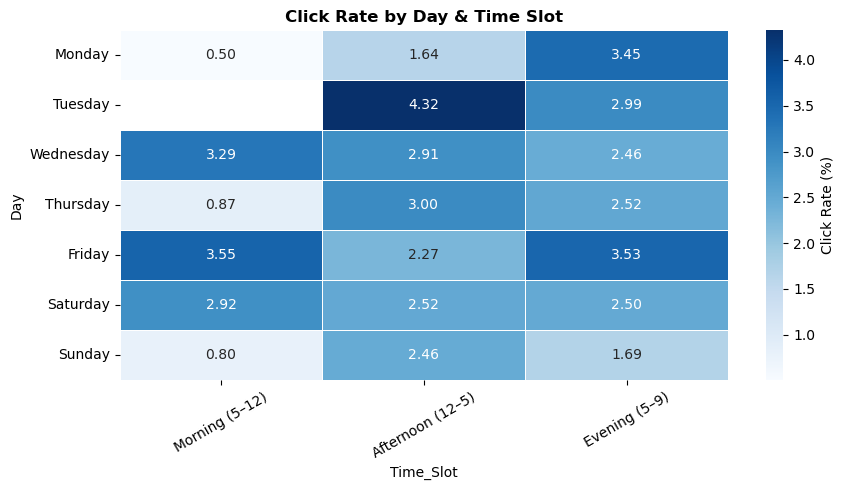

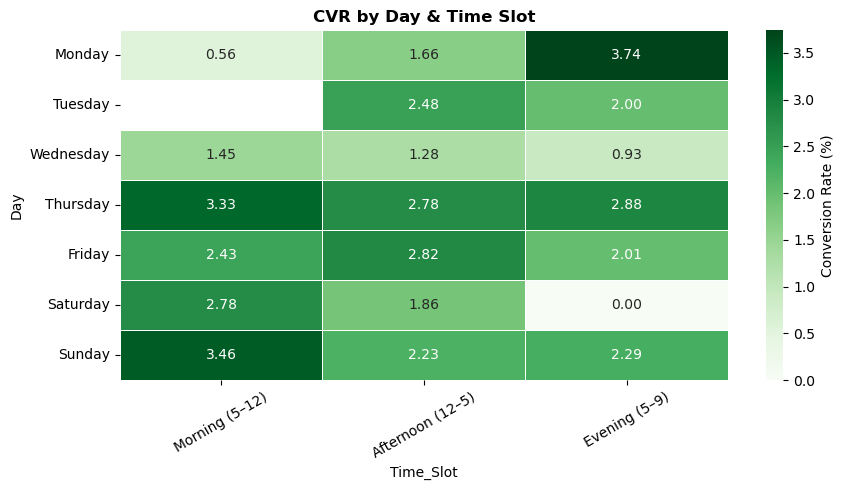

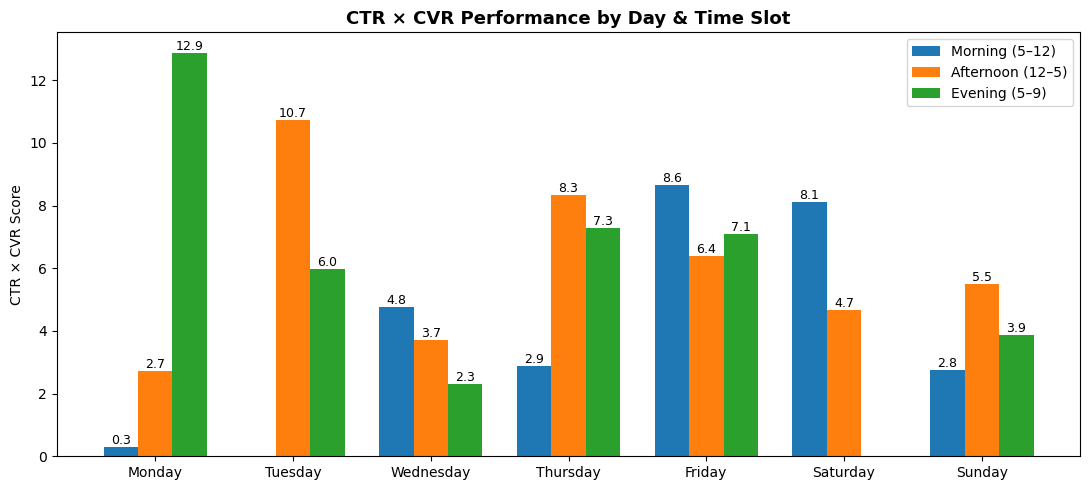

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# LOAD DATA
# -----------------------------
file_path = r"C:\Users\HP\Documents\Avon_Heatmap_source_sheet.xlsx"
df = pd.read_excel(file_path)

# -----------------------------
# CLEAN & STANDARDIZE
# -----------------------------
df = df[["Day", "Time Slot", "Total Delivered", "Clicks", "Orders"]]
df.columns = ["Day", "Time_Slot", "Delivered", "Clicks", "Orders"]

df["Day"] = df["Day"].astype(str).str.strip()
df["Time_Slot"] = df["Time_Slot"].astype(str).str.strip()

df = df.dropna(subset=["Day", "Time_Slot", "Delivered"])
df = df[df["Delivered"] > 0]

# -----------------------------
# METRICS
# -----------------------------
df["Click Rate"] = (df["Clicks"] / df["Delivered"]) * 100
df["CVR"] = np.where(df["Clicks"] > 0,
                     (df["Orders"] / df["Clicks"]) * 100,
                     np.nan)

df["Score"] = df["Click Rate"] * df["CVR"]

# -----------------------------
# OUTLIER REMOVAL (IQR)
# -----------------------------
Q1 = df["Score"].quantile(0.25)
Q3 = df["Score"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["Score"] >= lower) & (df["Score"] <= upper)]

# -----------------------------
# AGGREGATE
# -----------------------------
agg = df.groupby(["Day", "Time_Slot"], as_index=False).agg({
    "Delivered": "sum",
    "Clicks": "sum",
    "Orders": "sum"
})

agg["Click Rate"] = (agg["Clicks"] / agg["Delivered"]) * 100
agg["CVR"] = np.where(agg["Clicks"] > 0,
                      (agg["Orders"] / agg["Clicks"]) * 100,
                      np.nan)

agg["Score"] = agg["Click Rate"] * agg["CVR"]

# -----------------------------
# ORDERING
# -----------------------------
day_order  = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
slot_order = ["Morning (5–12)", "Afternoon (12–5)", "Evening (5–9)"]

click_pivot = agg.pivot(index="Day", columns="Time_Slot", values="Click Rate")
cvr_pivot   = agg.pivot(index="Day", columns="Time_Slot", values="CVR")
score_pivot = agg.pivot(index="Day", columns="Time_Slot", values="Score")

click_pivot = click_pivot.reindex(day_order)[slot_order]
cvr_pivot   = cvr_pivot.reindex(day_order)[slot_order]
score_pivot = score_pivot.reindex(day_order)[slot_order]

# =====================================================
# 1️⃣ CTR HEATMAP
# =====================================================
plt.figure(figsize=(9,5))
sns.heatmap(click_pivot, annot=True, fmt=".2f",
            cmap="Blues", linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Click Rate (%)"})

plt.title("Click Rate by Day & Time Slot", fontsize=12, weight="bold")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# =====================================================
# 2️⃣ CVR HEATMAP
# =====================================================
plt.figure(figsize=(9,5))
sns.heatmap(cvr_pivot, annot=True, fmt=".2f",
            cmap="Greens", linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Conversion Rate (%)"})

plt.title("CVR by Day & Time Slot", fontsize=12, weight="bold")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# =====================================================
# 3️⃣ CTR × CVR PERFORMANCE BAR GRAPH
# =====================================================
score_pivot = score_pivot.fillna(0)

x = np.arange(len(score_pivot.index))
width = 0.25

plt.figure(figsize=(11,5))

bars1 = plt.bar(x - width, score_pivot["Morning (5–12)"], width,
                label="Morning (5–12)")

bars2 = plt.bar(x, score_pivot["Afternoon (12–5)"], width,
                label="Afternoon (12–5)")

bars3 = plt.bar(x + width, score_pivot["Evening (5–9)"], width,
                label="Evening (5–9)")

# Value labels (optional)
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        val = bar.get_height()
        if val > 0:
            plt.text(bar.get_x() + bar.get_width()/2, val,
                     f"{val:.1f}",
                     ha='center', va='bottom', fontsize=9)

plt.xticks(x, score_pivot.index)
plt.ylabel("CTR × CVR Score")
plt.title("CTR × CVR Performance by Day & Time Slot", fontsize=13, weight="bold")
plt.legend()
plt.tight_layout()
plt.show()
